In [1]:
import feos, si_units as si, numpy as np, sys
import TERNARY_CLASS as TC
sys.path.append("..")
import PLOT_SETTINGS as ps
from molmass import Formula

In [2]:
import importlib.metadata
print(importlib.metadata.version("feos"))

0.9.3


In [3]:
parameters      = feos.Parameters.from_json(["carbon dioxide", "hydrogen", "argon"], "../parameters.json")          
n_total         = 1.0 * si.MOL
CO2_comp        = 0.95
feeds           = TC.generate_feeds(CO2=0.95, n_points=4)
eos             = feos.HelmholtzEnergyFunctional.pcsaft(parameters)

TC.print_array2d(feeds)
parameters

  i |         z1 |         z2 |         z3
---------------------------------------------------------
  1 |       0.9500       0.0167       0.0333
  2 |       0.9500       0.0333       0.0167


|component|molarweight|m|sigma|epsilon_k|
|-|-|-|-|-|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|
|hydrogen|2.016|1.0|3.002|51.343|
|argon|39.962|1.0|3.37751|117.80903|

In [4]:
components      = TC.components(parameters)
molar_masses    = [Formula(c).mass for c in components]  # g/mol
T_initial_guess = 200
verbose         = True
P_TOL           = 0.001  # Pressure [bar] tolerance for flash calculations excempting at the saturation points
T_STEP          = 10      # Temperature step for bubble/dew curve calculations (K)
P_STEP          = 5      # Pressure step for flash calculations (bar)
PT_results      = {}
VLE_DFT         = {}


Feed 1: z = [0.95       0.01666667 0.03333333]
Critical Point: T = 305.77 K, P = 90.42 bar
Dew calculation failed at T = 300 K: Iteration resulted in trivial solution.

Feed 2: z = [0.95       0.03333333 0.01666667]
Critical Point: T = 306.11 K, P = 93.54 bar
Bubble calculation failed at T = 300 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 300 K: Iteration resulted in trivial solution.

feed_1:
  T = 200 K: P_bubble = 52.33 bar, P_dew = 2.52 bar
  T = 210 K: P_bubble = 50.26 bar, P_dew = 4.11 bar
  T = 220 K: P_bubble = 49.29 bar, P_dew = 6.37 bar
  T = 230 K: P_bubble = 49.42 bar, P_dew = 9.47 bar
  T = 240 K: P_bubble = 50.69 bar, P_dew = 13.59 bar
  T = 250 K: P_bubble = 53.19 bar, P_dew = 18.95 bar
  T = 260 K: P_bubble = 57.02 bar, P_dew = 25.77 bar
  T = 270 K: P_bubble = 62.30 bar, P_dew = 34.31 bar
  T = 280 K: P_bubble = 69.12 bar, P_dew = 44.92 bar
  T = 290 K: P_bubble = 77.49 bar, P_dew = 58.07 bar
T = 200 K | P_flash = 2.52 | z = [0.95     0.01

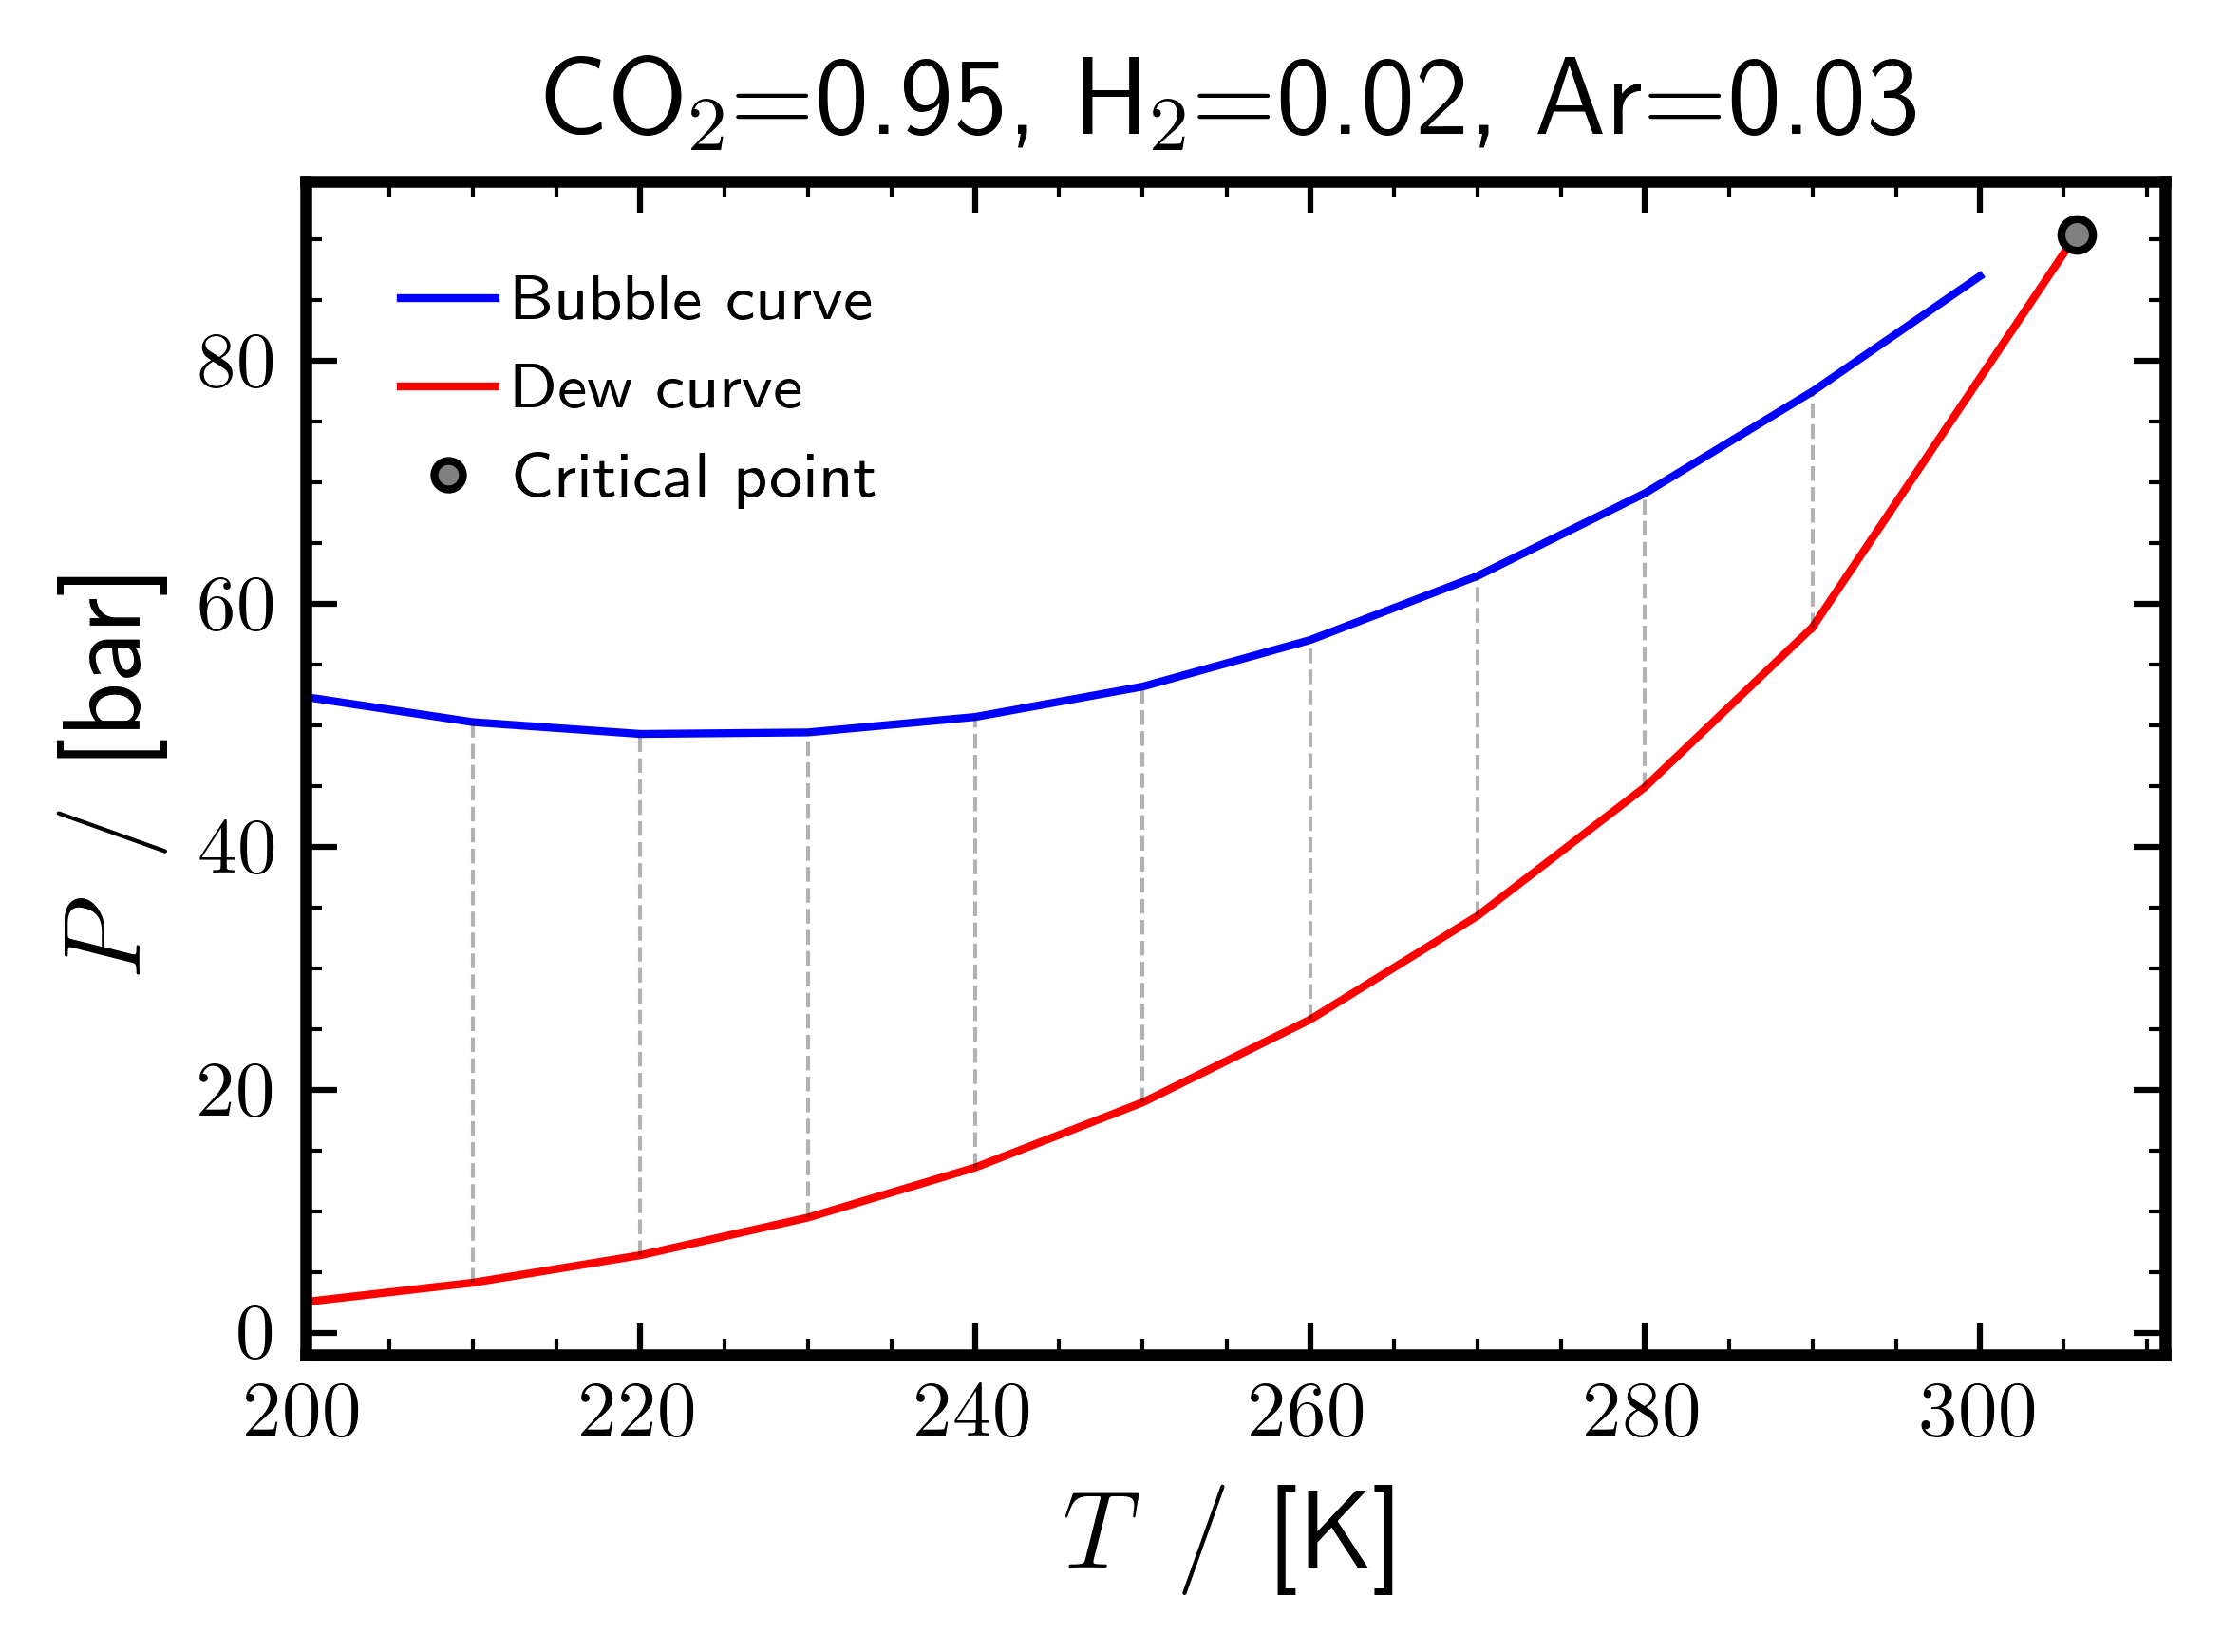

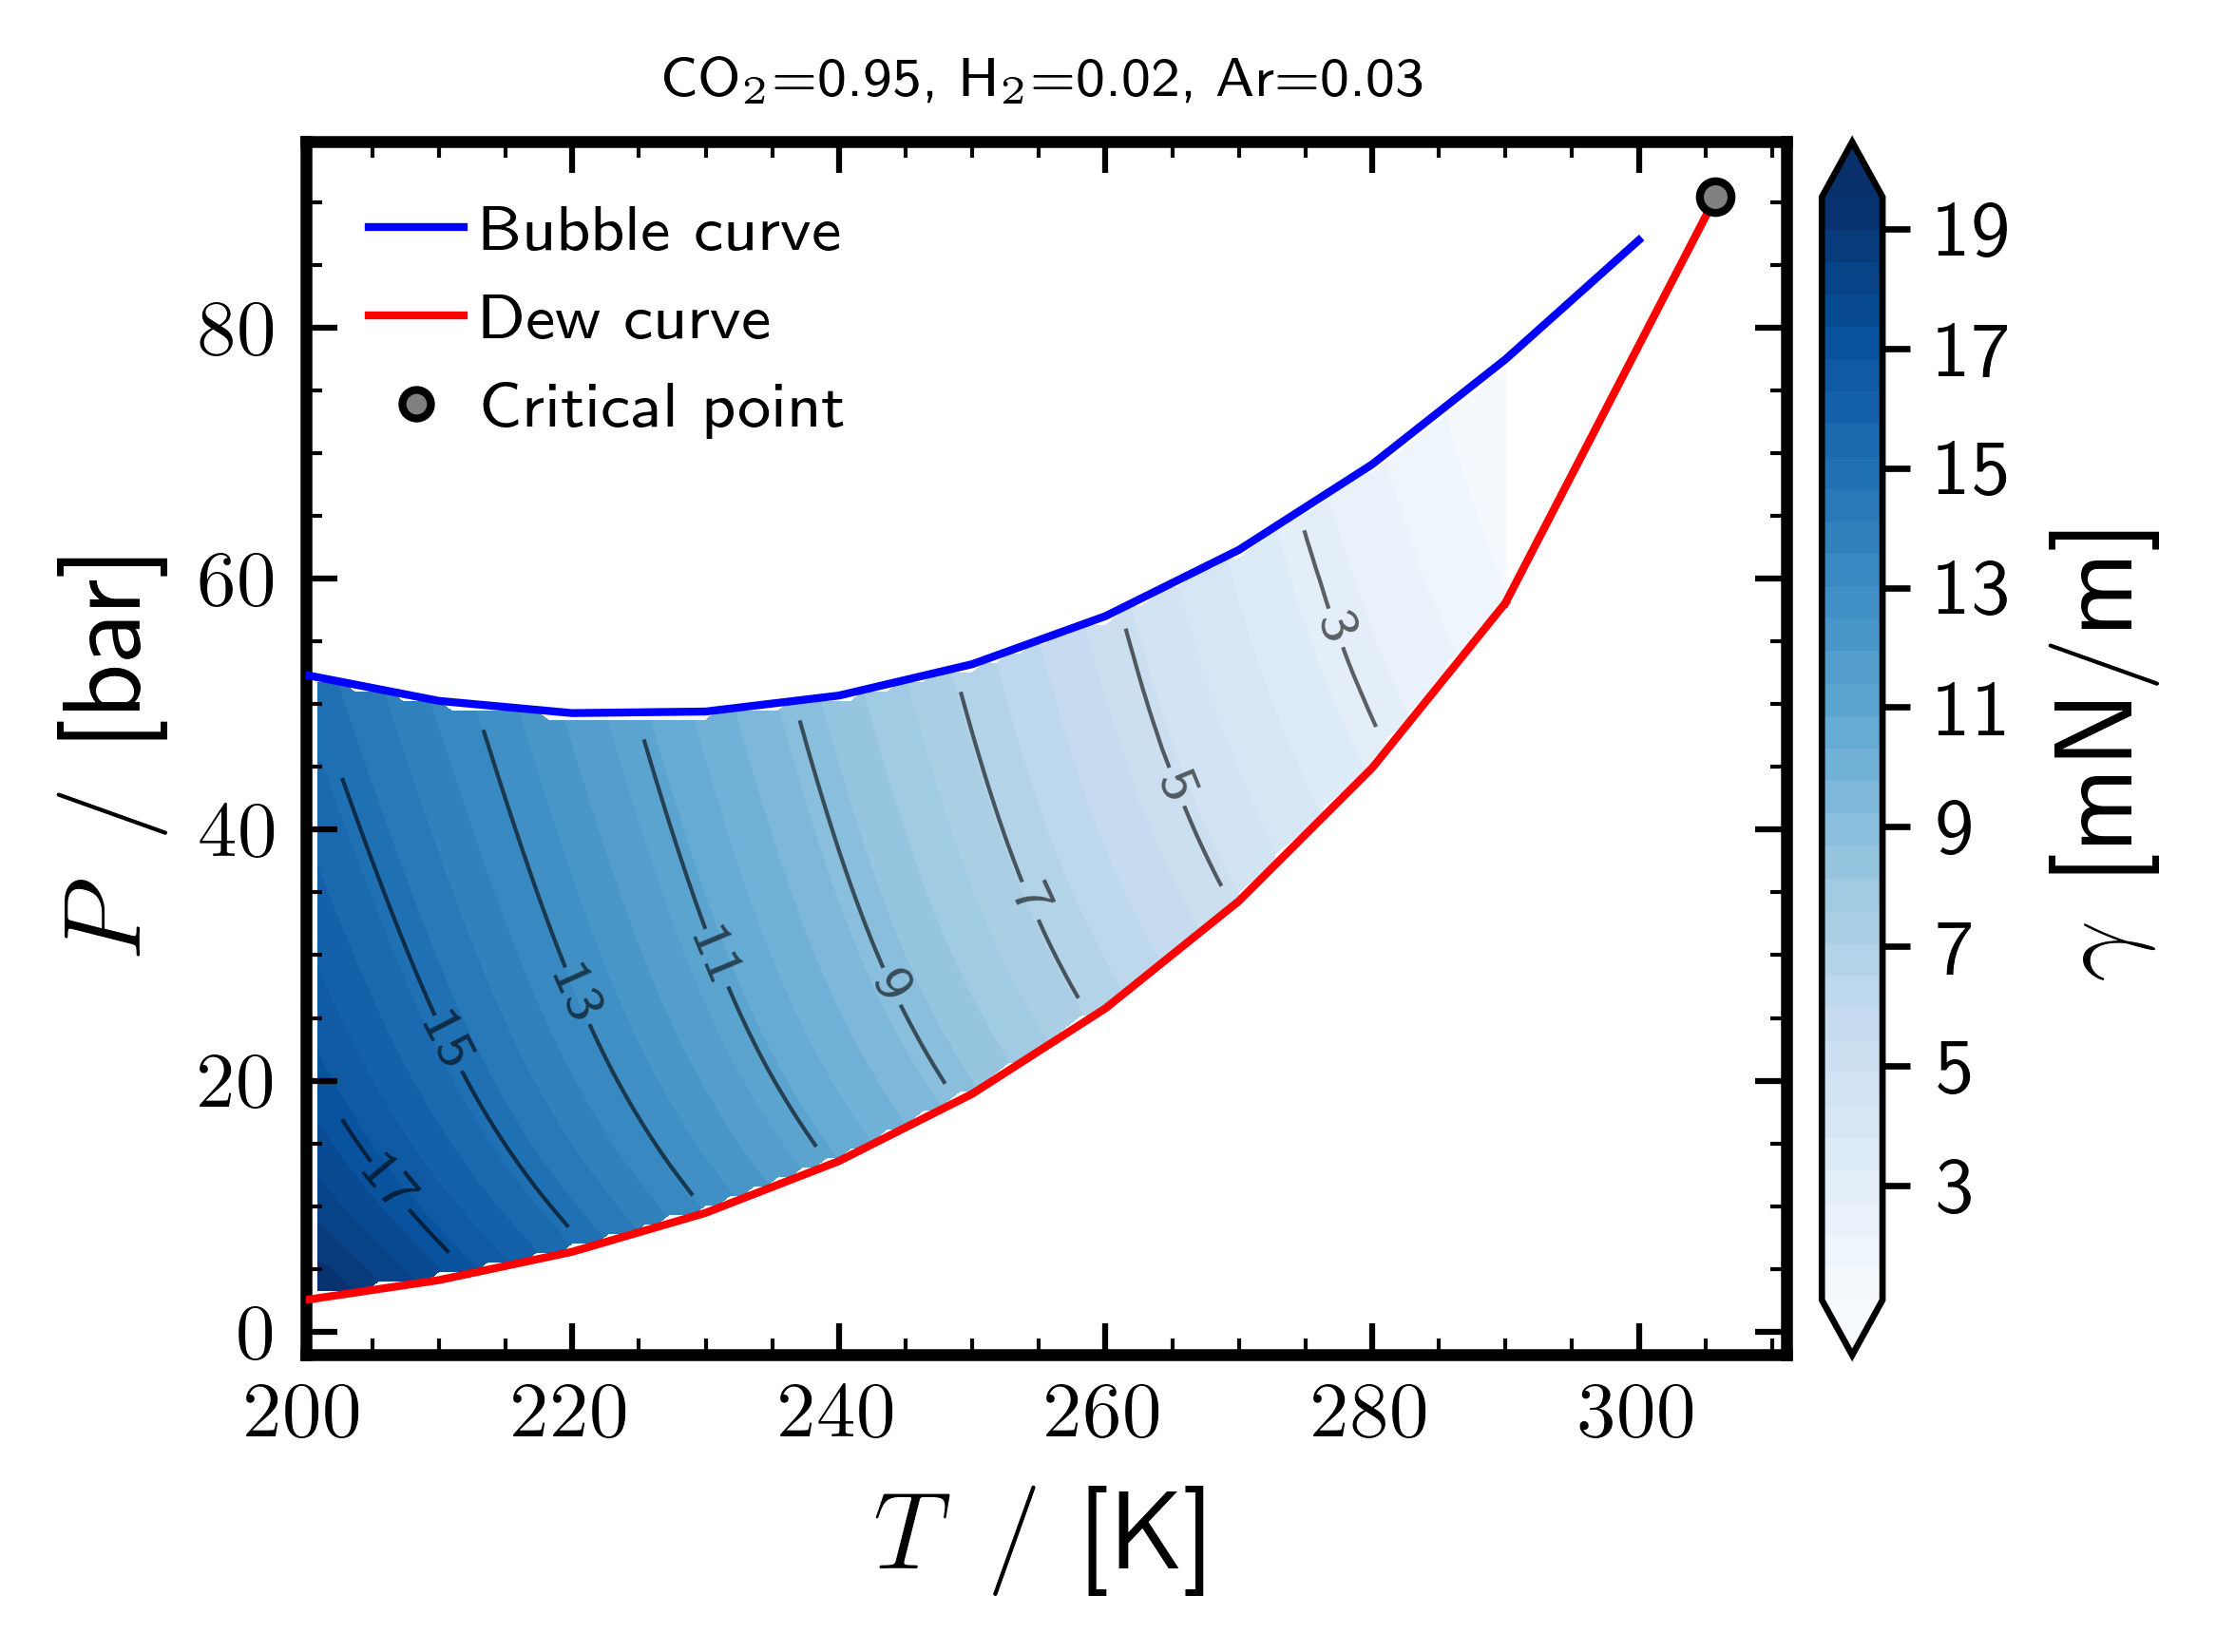

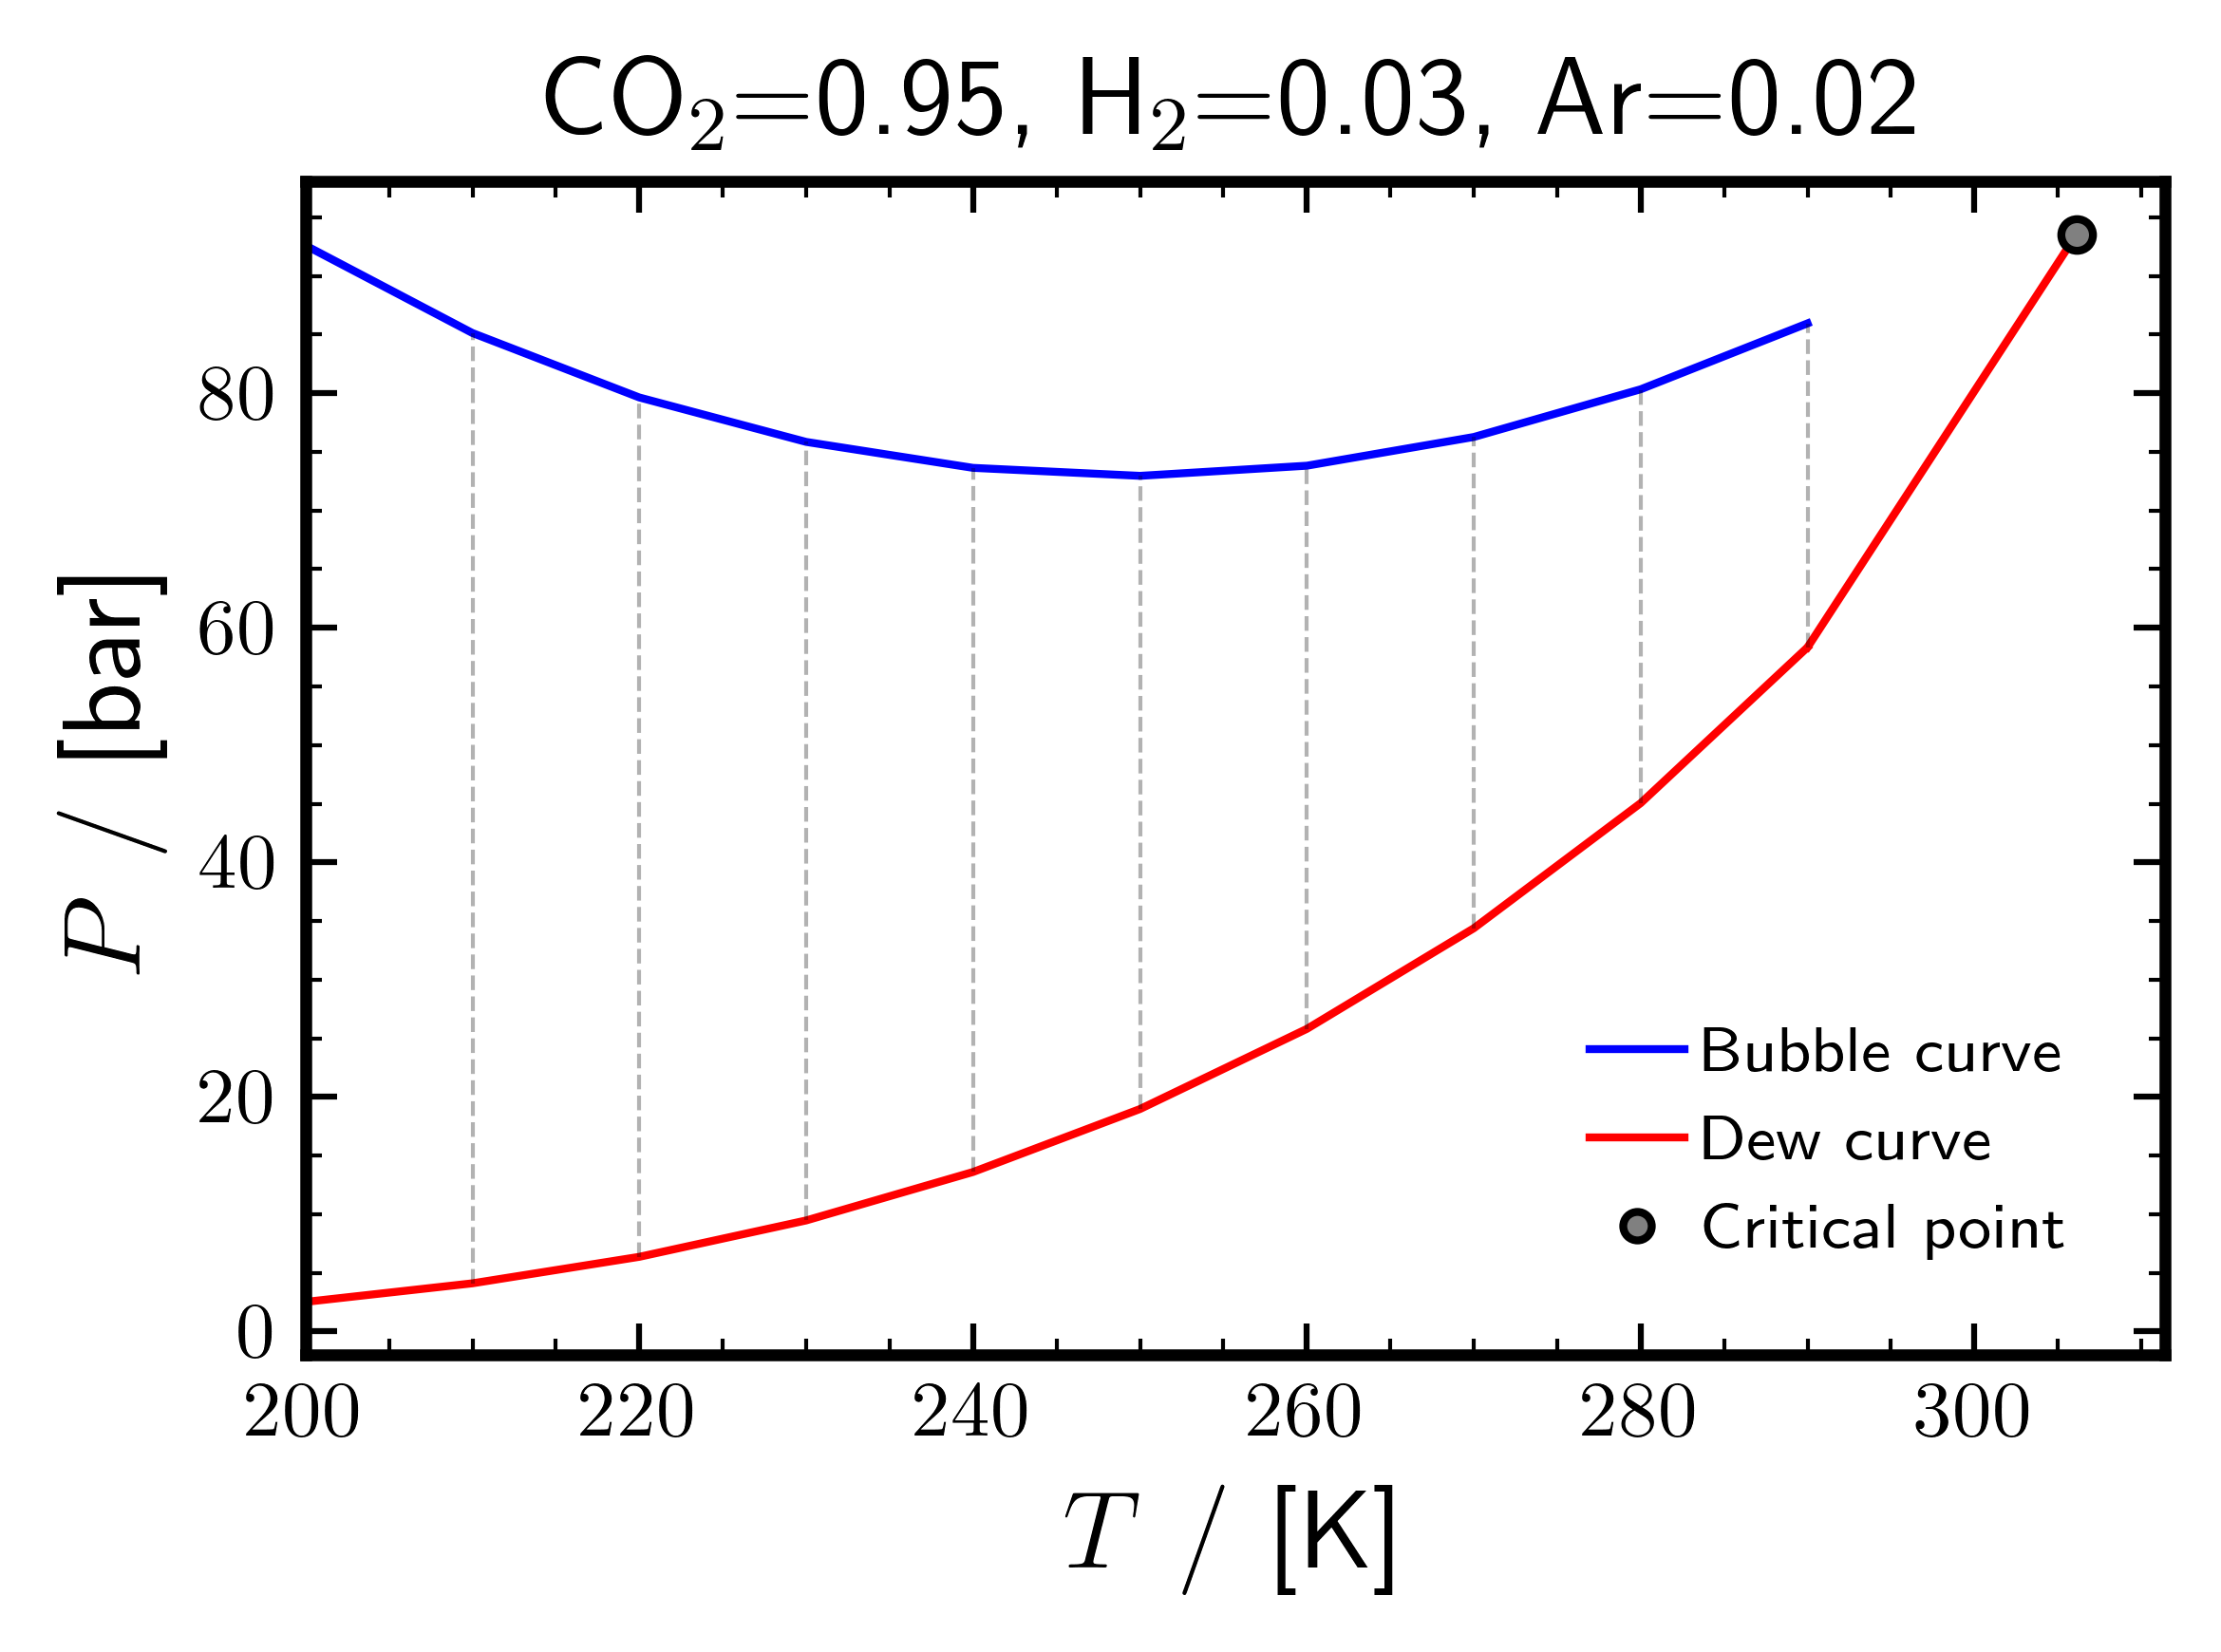

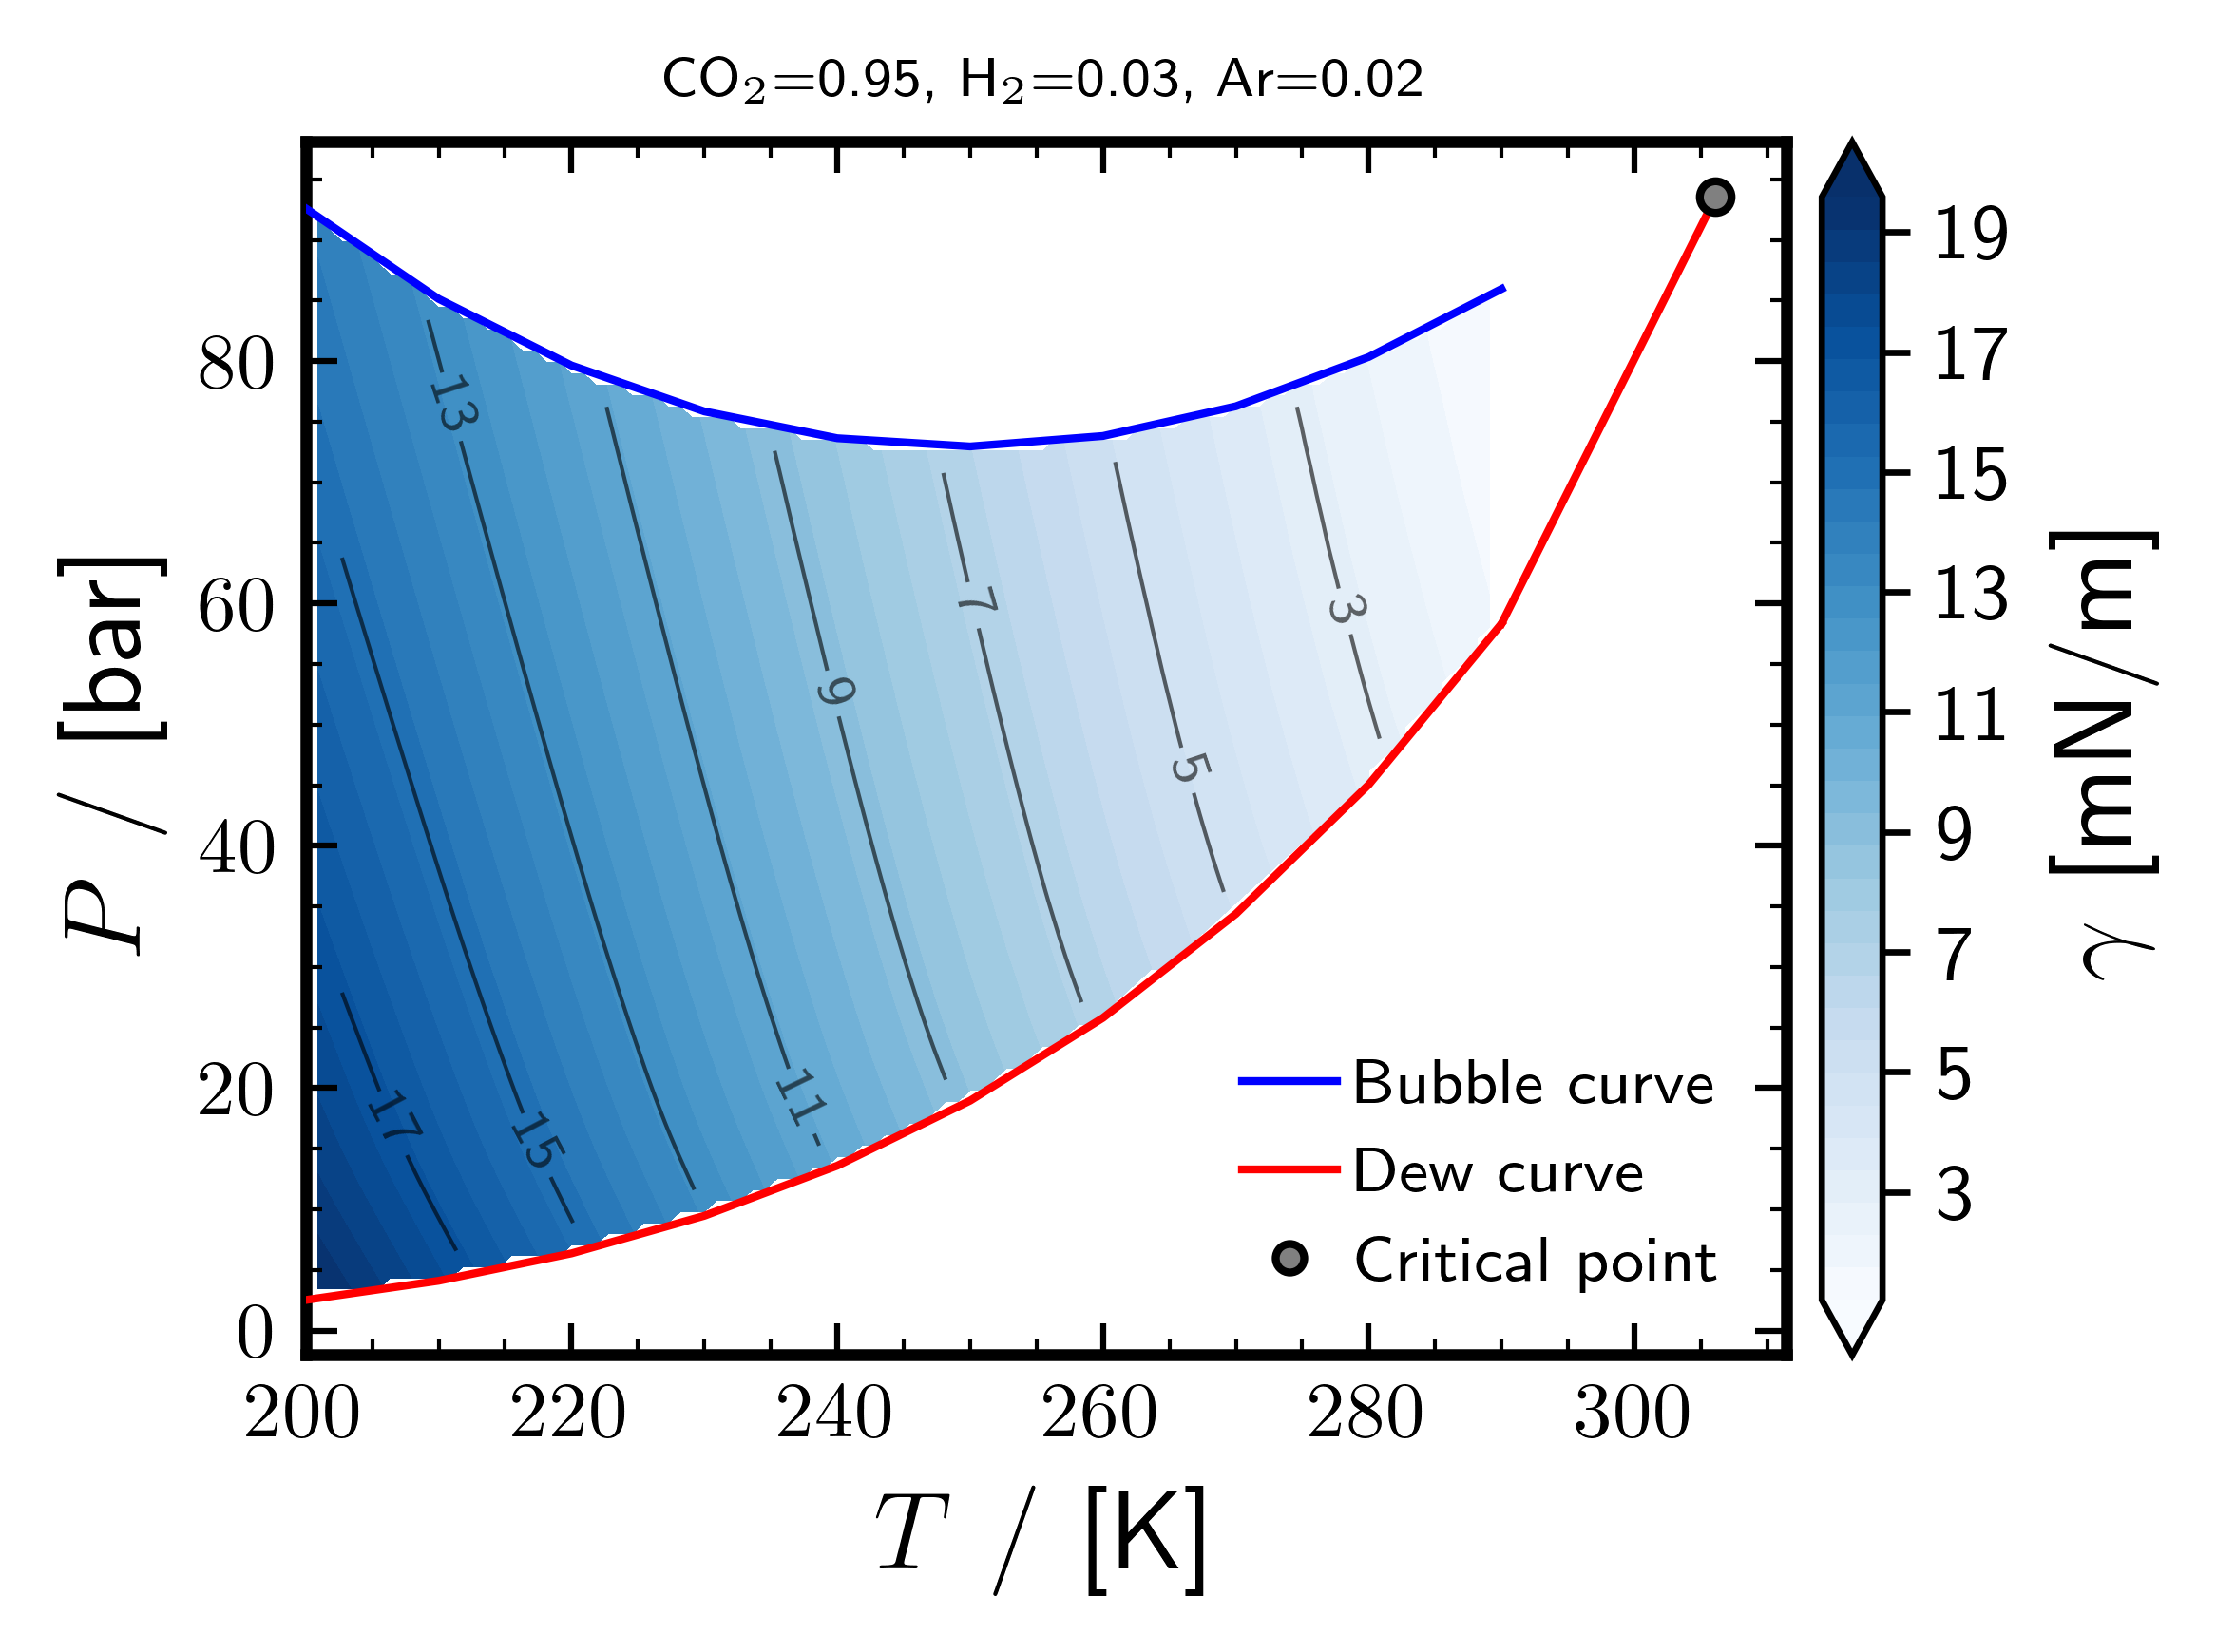

In [6]:
for k, z in enumerate(feeds, start=1):
    
    # --- normalize + mole amounts ---
    z = TC.normalize_z(z)
    feed = TC.compute_feed_moles(z, n_total)
    
    if verbose:
        print(f"\nFeed {k}: z = {z}") 
    
    # --- critical point at this composition ---
    CT, CP = TC.compute_CT(feos, eos, z*si.MOL, T_guess=T_initial_guess)
    if verbose:
        print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")
    
    # ---- compute bubble and dew curves ----
    T_values                    = range(int(T_initial_guess), int(CT / si.KELVIN) + 1, T_STEP)
    T_bubble, bubble_pressures  = TC.compute_bubble_curve(eos, T_values, feed, verbose=verbose)
    T_dew, dew_pressures        = TC.compute_dew_curve(eos, T_values, feed, verbose=verbose)
    
    PT_results[f"feed_{k}"] = {
        "z": [round(float(x), 6) for x in np.asarray(z, dtype=float)],
        "TC_K": round(float(CT / si.KELVIN), 2),
        "PC_bar": round(float(CP / si.BAR), 2),
        "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble, bubble_pressures)],
        "dew":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew, dew_pressures)],
    }

######################## PT phase digram spcae sweep , TP flash, and cDFT computations #################

for feed_key, feed in PT_results.items():

    TP_z        = np.array(feed.get("z", []))
    fig, ax     = TC.plot_PT(PT_results, feed_key, parameters)
    
    bub         = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("bubble", [])}
    dew         = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("dew", [])}
    common_T    = sorted(set(bub) & set(dew))

    # ---- Initialize unified storage for this FIXED feed composition ----
    VLE_DFT[feed_key] = {
        "z": TP_z.tolist(),
        "phase_envelope": {
            "bubble_curve": [{"T_K": T, "P_bar": bub[T]} for T in sorted(bub.keys())],
            "dew_curve": [{"T_K": T, "P_bar": dew[T]} for T in sorted(dew.keys())],
            "isothermal_lines": [
                {"T_K": T, "P_bubble_bar": bub[T], "P_dew_bar": dew[T]} 
                for T in common_T
            ]
        },
        "interfacial_data": {}
    }
    
    if verbose:
        print(f"\n{feed_key}:")
        for T in common_T:
            print(f"  T = {T} K: P_bubble = {bub[T]:.2f} bar, P_dew = {dew[T]:.2f} bar")
    
    if common_T:
        for T in common_T:
            
            P_b = bub[T]
            P_d = dew[T]

            if P_b >= P_d:
                
                pressures = np.linspace(P_d + P_TOL, P_b - P_TOL, 10)
                
                # ---- optional: PLOT ----
                ax.plot([T, T], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha=0.3)
                
                # Initialize list for this temperature
                VLE_DFT[feed_key]["interfacial_data"][T] = []
                
                for P in pressures:
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} | z = {TP_z}")
                       
                    # --- TP flash ---
                    try:
                        eq, x, y, liquid_density, vapor_density = TC.tp_flash(
                            feos, eos, T*si.KELVIN, P*si.BAR, TP_z*si.MOL, molar_masses)
                    except Exception as e:
                        print(f"TP flash failed for z = {TP_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        continue
                    
                    # --- planar interface & surface tension ---
                    interface = TC.build_planar_interface(
                        eq, critical_temperature=CT, n_grid=500, l_grid=100.0)
                    
                    try:
                        gamma_mN_m, interfacial_thickness_nm, (E_1, E_2, E_3) = \
                            TC.solve_interface_properties(interface, si)
                    except Exception as e:
                        print(f"Surface tension calculation failed for z = {TP_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        gamma_mN_m = np.nan
                        interfacial_thickness_nm = np.nan
                        E_1, E_2, E_3 = np.nan, np.nan, np.nan
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")

                    # ---- Use TC.row_append for consistent formatting ----
                    row_data = TC.row_append(
                        x, y, liquid_density, vapor_density, 
                        CT, gamma_mN_m, interfacial_thickness_nm, 
                        components, (E_1, E_2, E_3))
                    
                    # Add T and P to the row
                    row_data["T_K"] = float(T)
                    row_data["P_bar"] = float(P)
                    
                    # Store in interfacial_data
                    VLE_DFT[feed_key]["interfacial_data"][T].append(row_data)
                    
    TC.save_plot(fig, f"PT_{feed_key}")
    
    fig_gamma = TC.plot_gamma_colormap(PT_results, VLE_DFT, feed_key, parameters)
    if fig_gamma is not None:
        ps.save_plot(fig_gamma, f"Gamma_{feed_key}")

summary = TC.VLE_DFT_summary(VLE_DFT)

if verbose:
    print(summary)
  
saved_files = TC.VLE_DFT_to_csv(VLE_DFT, verbose=verbose)